In [ ]:
import os

import colorcet as cc
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import xarray as xr



In [2]:
base_dir = os.path.dirname(os.path.abspath('')).split(os.sep + 'evaluations')[0]
data_dir = os.path.sep.join([base_dir, '..', 'data', 'interim', 'ERAI', 'HIRHAM5', 'firnpack'])

In [3]:
years = range(1980, 2017)
dropvars = ['tsl', 'sn', 'evspsbl', 'gld', 'rogl', 'tradsm', 'sradsm', 'supimp', 'rfrz']
chunks_init = {"time": 1024, "y": 64, "x": 64}
ds_all = xr.open_mfdataset(
    [f"{data_dir}/Daily2D_GRL_{year}.nc" for year in years],
    concat_dim="time",
    combine="nested",
    chunks=chunks_init
).drop_vars(dropvars)

In [118]:
ds_yearly = xr.open_dataset(f"{data_dir}/Yearly2D_GRL_1980-2016.nc").sel(time=slice('1990', '2016'))
ds_jja = xr.open_dataset(f"{data_dir}/JJA2D_GRL_1980-2016.nc").sel(time=slice('1990', '2016'))

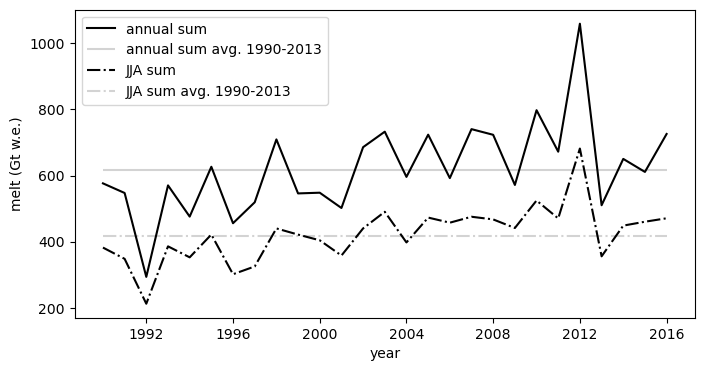

In [119]:
cmap = mcolors.ListedColormap(cc.glasbey_category10[4:10])
colors = [mcolors.to_hex(c) for c in cmap.colors]

scaling_factor = 1.796553703424 / 58391
plt.figure(figsize=(8, 4))
yearly_melt = ds_yearly['snmel'].sum(dim=['y', 'x'])*scaling_factor
plt.plot(ds_yearly['time'], ds_yearly['snmel'].sum(dim=['y', 'x'])*scaling_factor, c='black')
mean_total_melt = yearly_melt.sel(time=slice('1990', '2013')).mean(dim=['time'])
plt.hlines(mean_total_melt, ds_yearly['time'][0], ds_yearly['time'][-1], colors='lightgrey', zorder=0)
jja_melt = ds_jja['snmel'].sum(dim=['y', 'x'])*scaling_factor*90
plt.plot(ds_yearly['time'], jja_melt, c='black', linestyle='-.')
mean_jja_melt = jja_melt.sel(time=slice('1990', '2013')).mean(dim=['time'])
plt.hlines(mean_jja_melt, ds_yearly['time'][0], ds_yearly['time'][-1], colors='lightgrey', linestyles='-.', zorder=0)
plt.xlabel('year')
plt.ylabel('melt (Gt w.e.)')

plt.legend(['annual sum', 'annual sum avg. 1990-2013', 'JJA sum', 'JJA sum avg. 1990-2013'])
plt.show()

In [27]:
ds_climat_smooth = xr.open_dataset(f"{data_dir}/climat_1990-2013_smoothed15.nc")
ds_climat_smooth

<xarray.Dataset> Size: 7GB
Dimensions:   (y: 602, x: 402, time: 366)
Coordinates:
    lon       (y, x) float32 968kB ...
    lat       (y, x) float32 968kB ...
  * time      (time) datetime64[ns] 3kB 1980-01-01T12:00:00 ... 1980-12-31T12...
Dimensions without coordinates: y, x
Data variables: (12/20)
    ahfl      (time, y, x) float32 354MB ...
    ahfs      (time, y, x) float32 354MB ...
    dlwrad    (time, y, x) float32 354MB ...
    dswrad    (time, y, x) float32 354MB ...
    evspsbl   (time, y, x) float32 354MB ...
    rainfall  (time, y, x) float32 354MB ...
    ...        ...
    sradsm    (time, y, x) float32 354MB ...
    albedom   (time, y, x) float32 354MB ...
    sn        (time, y, x) float32 354MB ...
    supimp    (time, y, x) float32 354MB ...
    tsl       (time, y, x) float32 354MB ...
    rfrz      (time, y, x) float32 354MB ...
Attributes:
    CDI:          Climate Data Interface version 2.4.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Wed Nov 05 17:09:04 2025: cdo ydaymean -mergetime Daily2D_G...
    CDO:          Climate Data Operators version 2.4.0 (https://mpimet.mpg.de...

1990
1991
1992
1993
1994
1995
1996
1997
1998
1999
2000
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016


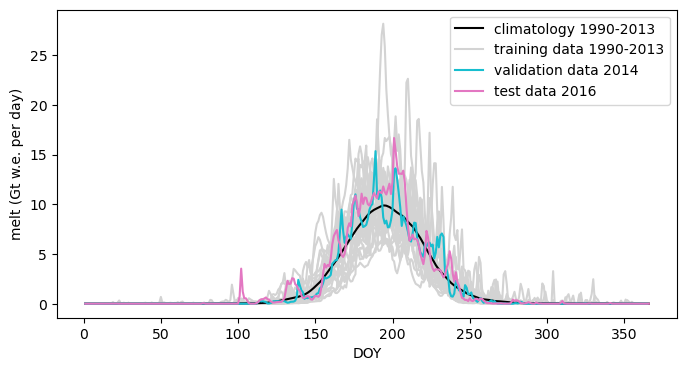

In [69]:
plt.figure(figsize=(8, 4))

plt.plot(ds_climat_smooth['time'].dt.dayofyear, ds_climat_smooth['snmel'].sum(dim=['y', 'x'])*scaling_factor, c='black', label='climatology 1990-2013')


for year in range(1990,2017):
    print(year)
    if year == 2016:
        style = {"color": colors[2]}
        label = 'test data 2016'
    elif year == 2014:
        style = {"color": colors[5]}
        label = 'validation data 2014'
    elif year == 2015:
        continue
    else:
        style = {"color": "lightgrey", "zorder": 0}
        label = None
        if year == 2013:
            label = 'training data 1990-2013'

    ds_this_year = ds_all['snmel'].sel(time=ds_all.time.dt.year == year).sum(dim=['y', 'x'])*scaling_factor
    plt.plot(ds_this_year['time'].dt.dayofyear, ds_this_year, **style, label=label)

plt.xlabel('DOY')
plt.ylabel('melt (Gt w.e. per day)')
plt.legend()
plt.show()

# Maps

In [70]:
ds_climat = xr.open_dataset(f"{data_dir}/climat_1990-2013.nc")
ds_climat

<xarray.Dataset> Size: 7GB
Dimensions:   (time: 366, y: 602, x: 402)
Coordinates:
  * time      (time) datetime64[ns] 3kB 2013-01-01T12:00:00 ... 2013-12-31T12...
    lon       (y, x) float32 968kB ...
    lat       (y, x) float32 968kB ...
Dimensions without coordinates: y, x
Data variables: (12/20)
    ahfl      (time, y, x) float32 354MB ...
    ahfs      (time, y, x) float32 354MB ...
    dlwrad    (time, y, x) float32 354MB ...
    dswrad    (time, y, x) float32 354MB ...
    evspsbl   (time, y, x) float32 354MB ...
    rainfall  (time, y, x) float32 354MB ...
    ...        ...
    sradsm    (time, y, x) float32 354MB ...
    albedom   (time, y, x) float32 354MB ...
    sn        (time, y, x) float32 354MB ...
    supimp    (time, y, x) float32 354MB ...
    tsl       (time, y, x) float32 354MB ...
    rfrz      (time, y, x) float32 354MB ...
Attributes:
    CDI:          Climate Data Interface version 2.4.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Wed Nov 05 17:09:04 2025: cdo ydaymean -mergetime Daily2D_G...
    CDO:          Climate Data Operators version 2.4.0 (https://mpimet.mpg.de...

/scratch/elkesc/.cache/ipykernel_2839890/3066453288.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('seismic')


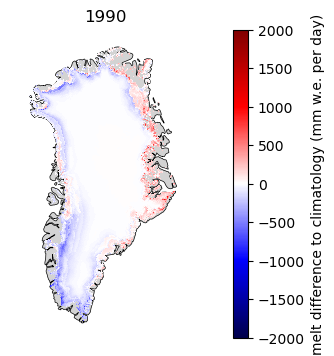

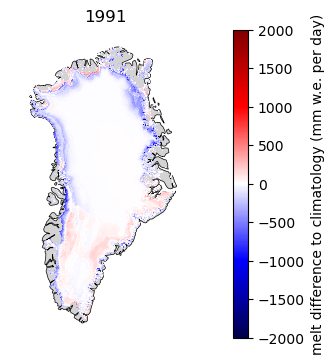

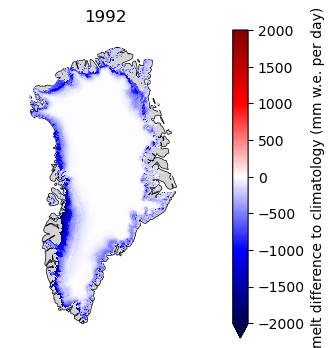

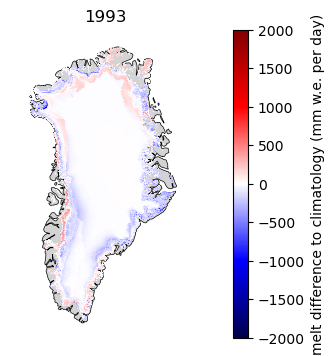

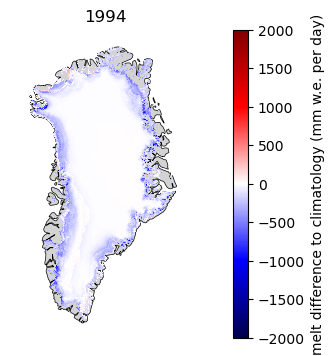

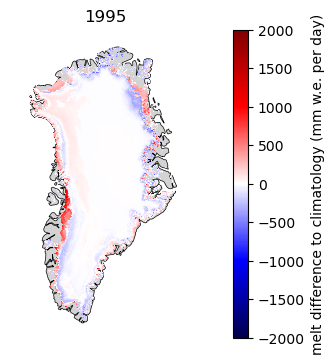

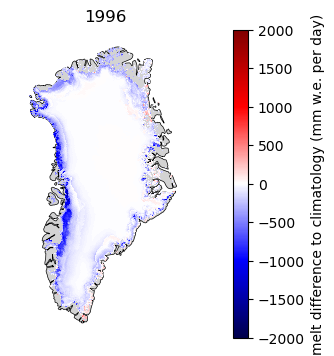

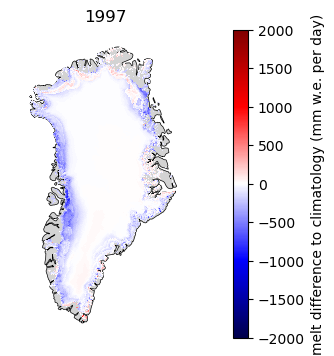

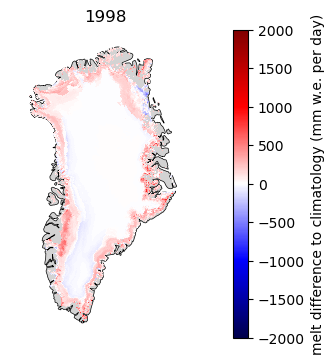

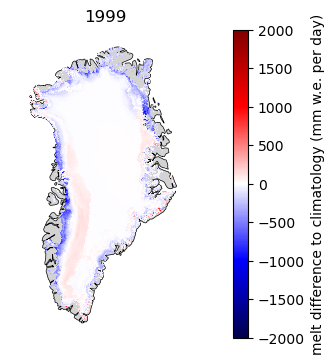

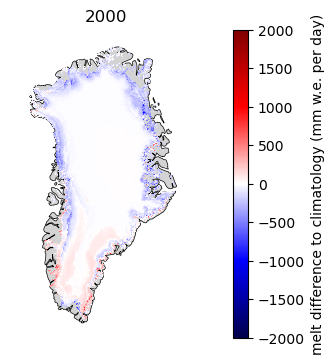

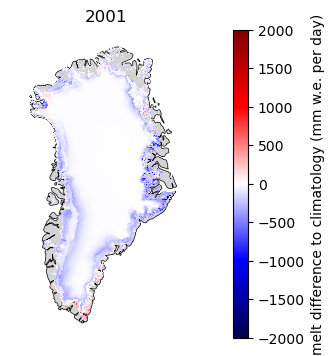

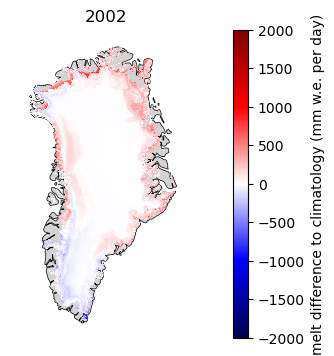

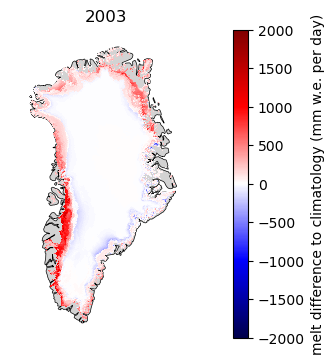

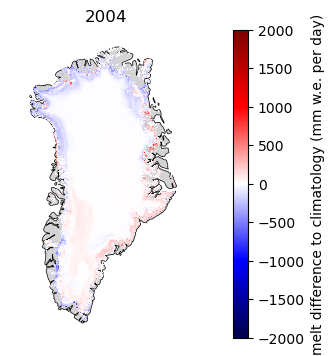

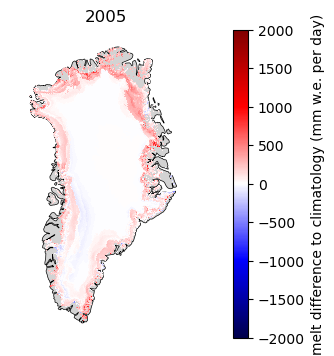

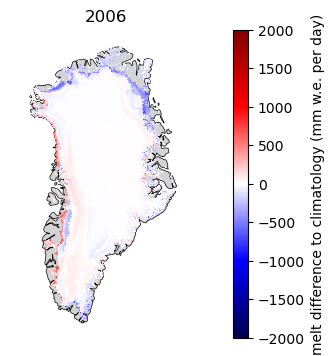

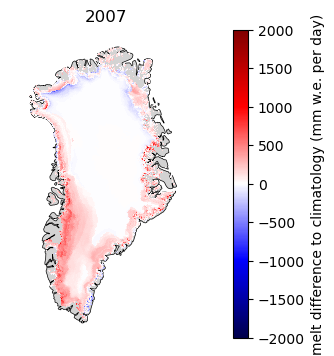

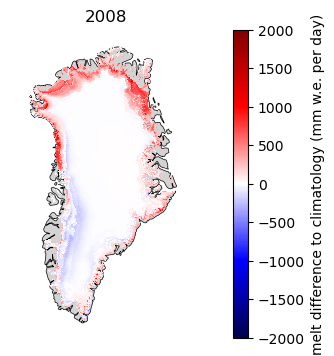

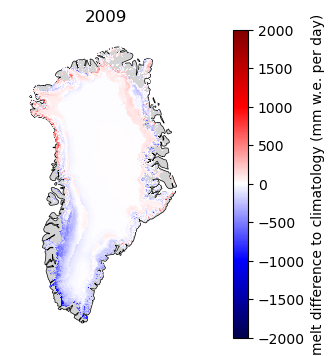

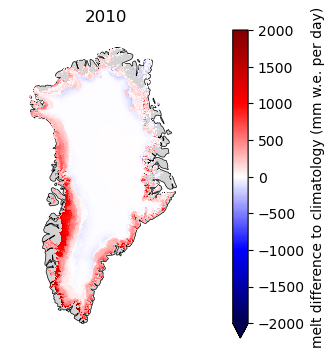

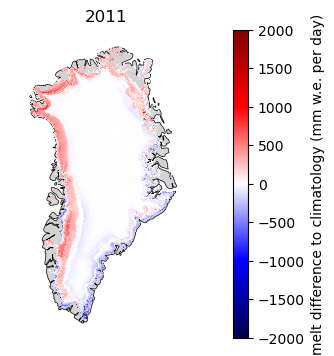

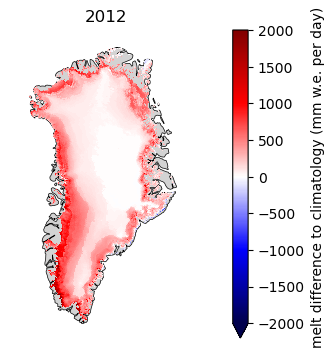

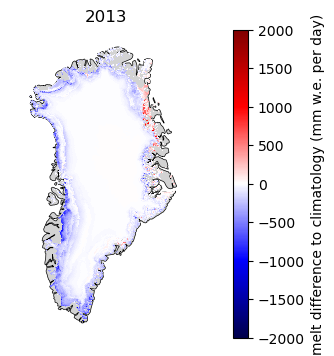

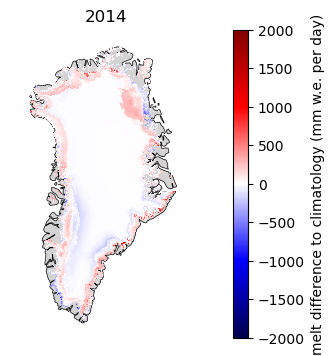

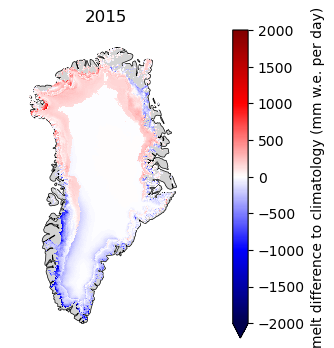

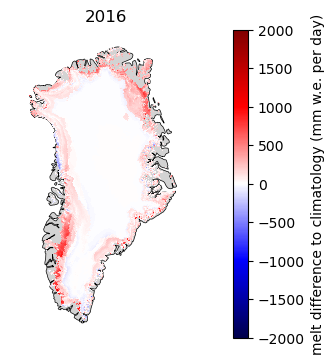

In [123]:
import sys
project_dir = os.path.sep.join(['..'])
sys.path.append(os.path.sep.join([project_dir , 'src']))
from GRL_plotter import plot_greenland_only
import cartopy.crs as ccrs

import matplotlib as mpl
cmap = mpl.cm.get_cmap('seismic')
cmap.set_bad((0, 0, 0, 0.0)) 

for year in range(1990,2017):
    ds_testyear = ds_yearly.sel(time = ds_yearly.time.dt.year == year)['snmel'].squeeze('time')
    mean_melt_map = ds_climat['snmel'].sum(dim='time').compute()
    diff = ds_testyear-mean_melt_map

    absdiff = max(abs(diff.min()), abs(diff.max()))

    fig = plt.figure(figsize=(8,4))
    display_crs = ccrs.NorthPolarStereo(central_longitude=-40)
    ax = fig.add_subplot(1, 1, 1, projection=display_crs)

    #norm = mcolors.TwoSlopeNorm(vmin=-absdiff, vcenter=0, vmax=absdiff)
    ax, p = plot_greenland_only(diff, ax=ax, pcolormesh_kwargs={'cmap': cmap, 'vmin': -2000, 'vmax': 2000})
    if diff.min() < -2000:
        extend = 'min'
        if diff.max() > 2000:
            extend = 'max'
    elif diff.max() > 2000:
        extend = 'min'
    else:
        extend=None

    ax.set_axis_off()
    ax.set_title(year)
    fig.colorbar(p, extend=extend, label='melt difference to climatology (mm w.e. per day)')
    plt.show()       
       

